In [24]:
import os
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import colormaps as cm
import pandas as pd

from graphufs.stacked_utils import get_channel_index
from graphcast.model_utils import dataset_to_stacked

In [2]:
def compute_forecast_error_ds(prediction: xr.Dataset, target: xr.Dataset, 
                              kind: str = "difference", 
                              dims_to_avg: list = ["lat", "lon", "grid_xt", "grid_yt",]) -> xr.Dataset:
    """
    Compute forecast error between prediction and target datasets.

    Args:
        prediction (xr.Dataset): Dataset of predicted variables.
        target (xr.Dataset): Dataset of target (truth) variables.
        kind (str): Type of error to compute. Options:
            - "difference" (default): prediction - target
            - "absolute": |prediction - target|
            - "squared": (prediction - target)^2

    Returns:
        xr.Dataset: Dataset containing forecast error for each common variable.
    """
    # Ensure we are working only with variables common to both datasets
    common_vars = list(set(prediction.data_vars).intersection(target.data_vars))

    error_vars = {}

    for var in common_vars:
        pred = prediction[var]
        targ = target[var]

        if kind == "difference":
            error = pred - targ
        elif kind == "absolute":
            error = abs(pred - targ)
        elif kind == "squared":
            error = (pred - targ) ** 2
        else:
            raise ValueError(f"Unknown error kind: {kind}")

        error.name = f"{var}_error"

        dims = [dim for dim in dims_to_avg if dim in error.dims]

        if len(dims)>0:
            error_vars[error.name] = error.mean(dim=dims)
        else:
            error_vars[error.name] = error

    return xr.Dataset(error_vars)

In [3]:
def cross_covariance(da: xr.DataArray, dim: str = "channels", norm: bool = False):
    """
    da shape: (time, lead_time, channels) or (time, lead_time, channels, lat, lon)
    Returns: xr.DataArray of shape (lead_time, channels_x, channels_y) 
             or (lead_time, channels_x, channels_y, lat, lon)
    """
    channels = da[dim].values
    lead_times = da["lead_time"].values
    statistic = "correlation" if norm else "covariance"

    has_spatial = "lat" in da.dims and "lon" in da.dims

    if has_spatial:
        lats = da["lat"].values
        lons = da["lon"].values
        out_mats = np.zeros((len(lead_times), len(channels), len(channels), len(lats), len(lons)))
    else:
        out_mats = np.zeros((len(lead_times), len(channels), len(channels)))

    for l, lt in enumerate(lead_times):
        # X shape: (n_init_times, n_channels) or (n_init_times, n_channels, lat, lon)
        da_X = da.sel(lead_time=lt).transpose("time", "channels", "lat", "lon")
        X = da_X.values
        
        if has_spatial:
            # X: (time, channels, lat, lon) -> (time, channels, lat*lon)
            n_time = da_X.sizes['time']; n_chan=da_X.sizes["channels"]
            n_lat = len(lats); n_lon = len(lons)
            print("shape of X:", X.shape)
            
            X = X.reshape(n_time, n_chan, -1)                      # (time, channels, lat*lon)
            X_centered = X - X.mean(axis=0, keepdims=True)        # (time, channels, lat*lon)
            n = X_centered.shape[0]

            if norm:
                std = X_centered.std(axis=0, keepdims=True)
                std = np.where(std == 0, 1, std)
                X_centered = X_centered / std

            # Covariance: einsum over time dimension
            # X_centered: (time, channels, spatial) -> (channels, channels, spatial)
            cov = np.einsum('tis,tjs->ijs', X_centered, X_centered) / (n - 1)
            out_mats[l] = cov.reshape(n_chan, n_chan, n_lat, n_lon)

        else:
            # X: (time, channels)
            X_centered = X - X.mean(axis=0, keepdims=True)
            n = X_centered.shape[0]

            if norm:
                std = X_centered.std(axis=0, keepdims=True)
                std = np.where(std == 0, 1, std)
                X_centered = X_centered / std

            out_mats[l] = (X_centered.T @ X_centered) / (n - 1)

    if has_spatial:
        out_da = xr.DataArray(
            out_mats,
            dims=["lead_time", "channels_x", "channels_y", "lat", "lon"],
            coords={
                "lead_time": lead_times,
                "channels_x": channels,
                "channels_y": channels,
                "lat": lats,
                "lon": lons,
            },
        )
    else:
        out_da = xr.DataArray(
            out_mats,
            dims=["lead_time", "channels_x", "channels_y"],
            coords={
                "lead_time": lead_times,
                "channels_x": channels,
                "channels_y": channels,
            },
        )

    out_da.attrs = {"description": f"forecast error cross-{statistic} per lead time"}
    return out_da

In [4]:
def load_model_prediction(config, eval_dates):
    """Loads prediction data based on the model's configuration."""
    pred_prefix = config["pred_prefix"]
    
    if pred_prefix == "persistence":
        num_missing_samples = config["num_missing_samples"] if config["num_missing_samples"] else 0
        return persistence_fcast(
            config["model_type"], config["run"], eval_dates, 
            num_missing_samples=num_missing_samples,
            fcast_nhours=config["duration"]
        )
    
    elif pred_prefix == "climatology":
        return climatology_fcast(
            config["model_type"], config["run"], eval_dates, 
            fcast_nhours=config["duration"]
        )
    
    elif pred_prefix == "graphufs":
        infer_dir = f"inference_{config['expt']}" if config["expt"] else "inference"
        location = os.path.join(SCRATCH_DIR, config["model_type"], config["run"], f"{infer_dir}/validation/")
        fname = f"{location}/{config['pred_prefix'].lower()}.{config['duration']}.zarr"
        model_pred = xr.open_zarr(fname)
        return model_pred.sel(time=slice(eval_dates[0], eval_dates[1]))
    
    else:
        raise ValueError(f"Unknown model type: {pred_prefix}")

In [5]:
def plot_spatially_averaged_covariance(ax,
                                       da: xr.DataArray,
                                       ticks: tuple = (0, 1, 8, 15, 22, 29),
                                       ticklabels: tuple = ("ssh", "so", "temp", "uo", "vo"),
                     title: str = None,
                     cmap: str = "RdBu_r",
                     vmin: float = None,
                     vmax: float = None,
                     add_colorbar: bool = False,
                     cbar_label: str = "",
                    ):
    """A correlation plot """
    cbar_kwargs={}
    if add_colorbar:
        cbar_kwargs['orientation'] = 'vertical'
        cbar_kwargs['pad'] = 0.1
        cbar_kwargs['aspect'] = 20
        cbar_kwargs['shrink'] = 0.9
        cbar_kwargs['label'] = cbar_label
        
    # Plot the heatmap
    p = da.plot(ax=ax, cmap=cmap, vmin=vmin, vmax=vmax, add_colorbar=add_colorbar, 
                cbar_kwargs=cbar_kwargs)

    # Draw separator lines
    for tick_pos in ticks[1:]:
        line_pos = tick_pos - 0.5
        ax.axvline(line_pos, color='gray', linestyle=':', linewidth=1.5)
        ax.axhline(line_pos, color='gray', linestyle=':', linewidth=1.5)

    # Clean up default axes
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel("")
    ax.set_ylabel("")

    # Add custom axis labels
    for i in range(len(ticks) - 1):
        start, end = ticks[i], ticks[i+1]
        midpoint = (start + end - 1) / 2
        label = ticklabels[i].upper() # Use uppercase for clarity

        ax.text(-0.07, midpoint, label, ha='center', va='center', rotation='vertical',
                fontsize=11, transform=ax.get_yaxis_transform(), clip_on=False)
        ax.text(midpoint, -0.07, label, ha='center', va='center',
                fontsize=11, transform=ax.get_xaxis_transform(), clip_on=False)

    if title is not None:
        ax.set_title(title, fontsize=12, pad=10)
    
    return p

In [6]:
# ---- Meta and Model Configs ----
TRUTHS = ["Replay"]
EVALUATION_DATES = ("2022-01-01T00", "2022-12-31T18")
FIG_DIR = os.path.join(os.getcwd(), "figures")
SCRATCH_DIR = "/pscratch/sd/n/nagarwal"

MODELS_CONFIG = [
    {
        "name": "Emulator-24h-MSE",
        "type": "emulator",
        "model_type": "ocn-only",
        "run": "R5",
        "expt": "T1M",
        "pred_prefix": "graphufs",
        "timestep": "24h",
        "duration": "240h",
        "description": "24hour-mse"
    },
    {
        "name": "Emulator-24h-MLoss",
        "type": "emulator",
        "model_type": "ocn-only",
        "run": "R8",
        "expt": "T2M",
        "pred_prefix": "graphufs",
        "timestep": "24h",
        "duration": "960h",
        "description": "24hour-maha"
    },
]

## Forecast Error

In [7]:
# ---- Main computation block ----
# Initialize dictionaries to store all results
all_forecast_error = {}
dims_to_avg = []
max_ilead = 10

# Main loop over models
for model_config in MODELS_CONFIG:
    model_name = model_config["name"]
    print(f"\nProcessing Model: {model_name}")
        
    all_forecast_error[model_name] = {}
        
    # Load the model prediction data once
    model_pred = load_model_prediction(model_config, EVALUATION_DATES)
        
    # Loop over the truth references for this model
    for truth_name in TRUTHS:
        print(f"Comparing against truth: {truth_name} ...")
            
        # Construct the path to the truth data
        if model_config["type"] in ["persistence", "climatology"]:
            # Logic to find the corresponding replay file for baselines
            run = "R5" if model_config['timestep'] == "24h" else "R4"
            expt = "T1M" if model_config['timestep'] == "24h" else "T3M"
            duration = "240h"
            location = os.path.join(SCRATCH_DIR, model_config["model_type"], run, f"inference_{expt}/validation/")
            fname = f"{location}/replay.{duration}.zarr"
        else:
            infer_dir = f"inference_{model_config['expt']}" if model_config["expt"] else "inference"
            location = os.path.join(SCRATCH_DIR, model_config['model_type'], model_config['run'], f"{infer_dir}/validation/")
            fname = f"{location}/{truth_name.lower()}.{model_config['duration']}.zarr"

        ref_truth = xr.open_zarr(fname)
            
        # Calculate all metrics for this model against this truth
        forecast_error = compute_forecast_error_ds(model_pred, ref_truth, kind="difference", dims_to_avg=dims_to_avg)
            
        # Store results
        all_forecast_error[model_name][truth_name] = forecast_error.isel(lead_time=slice(None, max_ilead))

print("\n --- Metric calculation complete!! ---")


Processing Model: Emulator-24h-MSE
Comparing against truth: Replay ...

Processing Model: Emulator-24h-MLoss
Comparing against truth: Replay ...

 --- Metric calculation complete!! ---


## Channel Meta data

In [8]:
# channel meta
meta = get_channel_index(model_pred, preserved_dims=("time","lead_time","lat","lon"))
meta

{0: {'varname': 'SSH'},
 1: {'varname': 'so', 'z_l': 0},
 2: {'varname': 'so', 'z_l': 1},
 3: {'varname': 'so', 'z_l': 2},
 4: {'varname': 'so', 'z_l': 3},
 5: {'varname': 'so', 'z_l': 4},
 6: {'varname': 'so', 'z_l': 5},
 7: {'varname': 'so', 'z_l': 6},
 8: {'varname': 'temp', 'z_l': 0},
 9: {'varname': 'temp', 'z_l': 1},
 10: {'varname': 'temp', 'z_l': 2},
 11: {'varname': 'temp', 'z_l': 3},
 12: {'varname': 'temp', 'z_l': 4},
 13: {'varname': 'temp', 'z_l': 5},
 14: {'varname': 'temp', 'z_l': 6},
 15: {'varname': 'uo', 'z_l': 0},
 16: {'varname': 'uo', 'z_l': 1},
 17: {'varname': 'uo', 'z_l': 2},
 18: {'varname': 'uo', 'z_l': 3},
 19: {'varname': 'uo', 'z_l': 4},
 20: {'varname': 'uo', 'z_l': 5},
 21: {'varname': 'uo', 'z_l': 6},
 22: {'varname': 'vo', 'z_l': 0},
 23: {'varname': 'vo', 'z_l': 1},
 24: {'varname': 'vo', 'z_l': 2},
 25: {'varname': 'vo', 'z_l': 3},
 26: {'varname': 'vo', 'z_l': 4},
 27: {'varname': 'vo', 'z_l': 5},
 28: {'varname': 'vo', 'z_l': 6}}

## Stacked Forecast Error and Error Covariance

In [9]:
stacked_forecast_error = {}
error_covariance = {}
preserved_dims = ("time", "lead_time","lat","lon")

for model_config in MODELS_CONFIG:
    print("Processing model:", model_config["name"])
    
    stacked_forecast_error[model_config["name"]] = {}
    error_covariance[model_config["name"]] = {}
    
    for truth in TRUTHS:
        print("Computing forecast error ...")
        stacked_forecast_error[model_config["name"]][truth] = dataset_to_stacked(all_forecast_error[model_config["name"]][truth], 
                                                                      preserved_dims=preserved_dims)
        print("Forecast error computed!!!")
        print(f"Computing error covariance against {truth}")
        error_covariance[model_config["name"]][truth] = cross_covariance(stacked_forecast_error[model_config["name"]][truth], dim="channels")

Processing model: Emulator-24h-MSE
Computing forecast error ...
Forecast error computed!!!
Computing error covariance against Replay
shape of X: (292, 29, 192, 384)
shape of X: (292, 29, 192, 384)
shape of X: (292, 29, 192, 384)
shape of X: (292, 29, 192, 384)
shape of X: (292, 29, 192, 384)
shape of X: (292, 29, 192, 384)
shape of X: (292, 29, 192, 384)
shape of X: (292, 29, 192, 384)
shape of X: (292, 29, 192, 384)
shape of X: (292, 29, 192, 384)
Processing model: Emulator-24h-MLoss
Computing forecast error ...
Forecast error computed!!!
Computing error covariance against Replay
shape of X: (292, 29, 192, 384)
shape of X: (292, 29, 192, 384)
shape of X: (292, 29, 192, 384)
shape of X: (292, 29, 192, 384)
shape of X: (292, 29, 192, 384)
shape of X: (292, 29, 192, 384)
shape of X: (292, 29, 192, 384)
shape of X: (292, 29, 192, 384)
shape of X: (292, 29, 192, 384)
shape of X: (292, 29, 192, 384)


## Spatially-Averaged Error Covariance

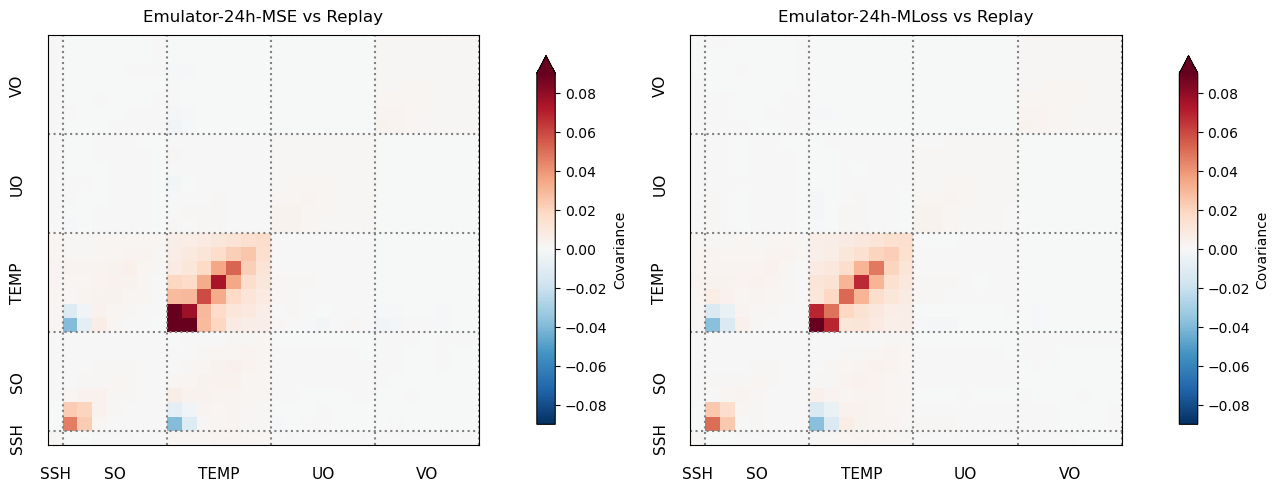

In [35]:
lead_time = 10 # in days
lead_time_hours = np.timedelta64(lead_time * 24, 'h')  # 10 days
vmin=-0.09; vmax=0.09
save_plot = False

nrows = len(TRUTHS)
ncols = len(MODELS_CONFIG)

fig, axes = plt.subplots(nrows, ncols, figsize=(6.5 * ncols, 5 * nrows))
axes = np.atleast_2d(axes)

for i, truth in enumerate(TRUTHS):
    for j, model_config in enumerate(MODELS_CONFIG):
        mat = error_covariance[model_config["name"]][truth].sel(lead_time=lead_time_hours, method="nearest")
        if "lat" in mat.dims:
            mat = mat.mean(dim="lat")
        if "lon" in mat.dims:
            mat = mat.mean(dim="lon")
            
        plot_spatially_averaged_covariance(axes[i, j], mat, title=f"{model_config['name']} vs {truth}", vmin=vmin, vmax=vmax, 
                        cmap="RdBu_r", add_colorbar=True, cbar_label="Covariance")

plt.tight_layout()
if save_plot:
    plt.savefig(f"./figures/{lead_time}-day_forecast_error_covariance_MSE_MLoss_24h_1IC.png", dpi=300)
plt.show()

## Error Covariance For a Given Pair of Variables

In [11]:
def search_dict(source_dict:dict, value: dict):
    key_value = None
    for key, val in source_dict.items():
        if val == value:
            key_value = key
            break

    return key_value

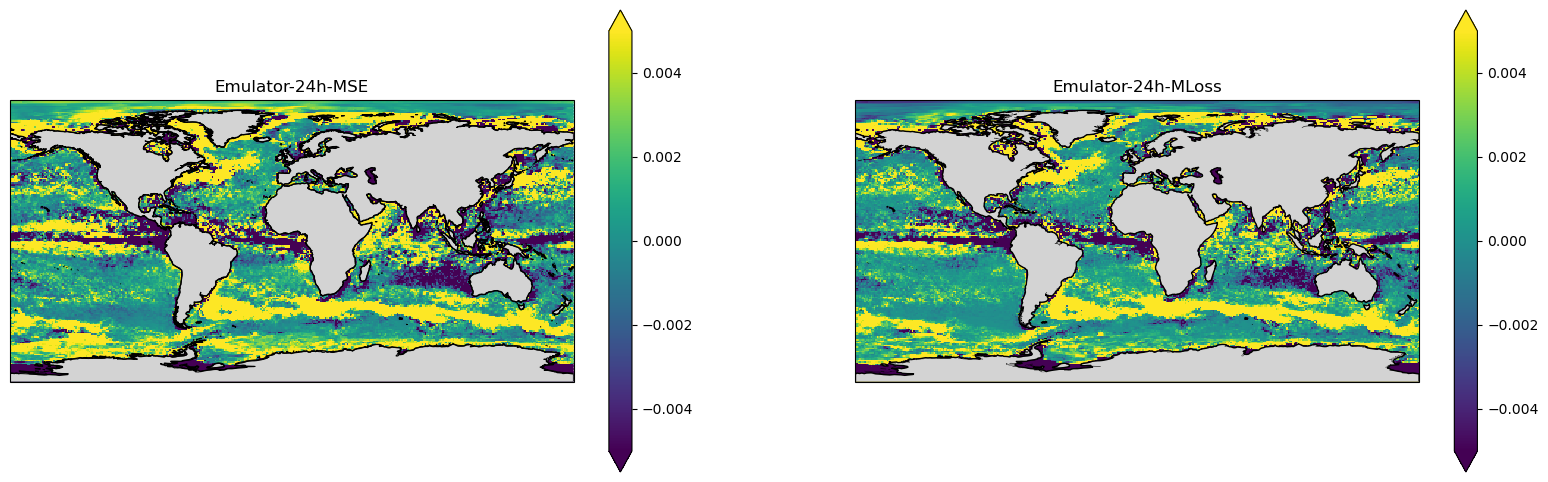

In [40]:
# define the covarying variables and lead_time_to_plot
var1 = {"varname": "temp", "z_l": 0}
var2 = {"varname": "so", "z_l": 0}
lead_time_to_plot = 9

# get their indices
idx1 = search_dict(meta, var1)
idx2 = search_dict(meta, var2)

# plot
fig, ax = plt.subplots(1,2, figsize=(20, 6), subplot_kw={"projection":ccrs.PlateCarree()})

# MSE-based
p1 = error_covariance['Emulator-24h-MSE']['Replay'].isel(channels_x=idx2, channels_y=idx1, lead_time=lead_time_to_plot).plot(ax=ax[0], vmin=-0.005, vmax=0.005)
p1.axes.set_title("Emulator-24h-MSE")
ax[0].add_feature(cfeature.LAND, zorder=1, edgecolor='k', facecolor='lightgray')
ax[0].coastlines(resolution='50m', color='black', linewidth=0.7)
# MLoss-based
p2 = error_covariance['Emulator-24h-MLoss']['Replay'].isel(channels_x=idx2, channels_y=idx1, lead_time=lead_time_to_plot).plot(ax=ax[1], vmin=-0.005, vmax=0.005)
p2.axes.set_title("Emulator-24h-MLoss")
ax[1].add_feature(cfeature.LAND, zorder=1, edgecolor='k', facecolor='lightgray')
ax[1].coastlines(resolution='50m', color='black', linewidth=0.2)

plt.show()